In [ ]:
# Cell 1: Setup

import tensorflow as tf
from tensorflow import keras                # type: ignore
from tensorflow.keras import layers         # type: ignore
import numpy as np
import matplotlib.pyplot as plt
import math

# GPU configuration for better performance and stability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    tf.config.optimizer.set_jit(True)

keras.mixed_precision.set_global_policy('mixed_float16')

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")
print(f"Compute dtype: {keras.mixed_precision.global_policy().compute_dtype}")

np.random.seed(42)
tf.random.set_seed(42)


# Constants and Hyperparameters
LATENT_DIM    = 32
KL_WEIGHT     = 1.0
KL_STEEPNESS  = 0.1
BATCH_SIZE    = 512
BASE_FILTERS  = 16
LEARNING_RATE = 0.001
LR_DECAY      = 0.75
WEIGHT_DECAY  = 0.0005
CLIPNORM      = 2.0
EPOCHS        = 200

BOTTLENECK_DIM = 4
MAX_LAYERS     = 5
LOSS_FUNCTION  = str('mse')         # 'mse' or 'bce'
ACTIVATION_OUT = str('tanh')     # 'tanh' or 'sigmoid'

IMAGE_SIZE_X = 32
IMAGE_SIZE_Y = 32
CHANNELS     = 3        # 1 for grayscale, 3 for RGB
STRIDE       = 2

STAGE_EPOCHS    = int(EPOCHS // MAX_LAYERS)
WARMUP_EPOCHS   = int(STAGE_EPOCHS // 10)
AES_PATIENCE    = 10
AES_SENSITIVITY = 0.075      # Lower is more sensitive
AES_MIN_DELTA   = 0.01
AES_START_EPOCH = int(STAGE_EPOCHS * 0.5)

2026-04-30 20:03:14.677335: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-30 20:03:15.189350: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-30 20:03:17.624619: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Compute dtype: float16


In [2]:
# Cell 2: Architecture

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = keras.random.normal(shape=keras.ops.shape(z_mean), dtype=z_mean.dtype)
        return z_mean + keras.ops.exp(0.5 * z_log_var) * epsilon


def build_encoder(num_layers, latent_dim=LATENT_DIM):
    inputs = keras.Input(shape=(IMAGE_SIZE_X, IMAGE_SIZE_Y, CHANNELS))
    x = inputs

    max_down = int(math.log2(IMAGE_SIZE_X // BOTTLENECK_DIM))
    num_down = max_down

    for i in range(max(num_layers, max_down)):
        filters = BASE_FILTERS * (2 ** min(i, num_layers - 1))
        stride  = STRIDE if i < max_down else 1

        # NxN conv to extract features and downsample
        x = layers.Conv2D(filters, 3, strides=stride, padding='same', activation='relu', use_bias=False, name=f'enc_conv_{i}')(x)
        
        # 1x1 conv for channel mixing
        x = layers.Conv2D(filters, 1, padding='same', activation='relu', use_bias=False, name=f'enc_1x1_{i}')(x)

    # Bottleneck: 3x3 convs produce z_mean and z_log_var as spatial maps
    # Local latent (biologically inspired)
    z_mean_map      = layers.Conv2D(latent_dim, 3, padding='same', name='z_mean', dtype='float32')(x)
    z_log_var_map   = layers.Conv2D(latent_dim, 3, padding='same', name='z_log_var', dtype='float32')(x)
    z               = Sampling()([z_mean_map, z_log_var_map])

    return keras.Model(inputs, [z_mean_map, z_log_var_map, z], name=f'encoder_L{num_layers}')


def build_decoder(num_layers, latent_dim=LATENT_DIM):
    max_down = int(math.log2(IMAGE_SIZE_X // BOTTLENECK_DIM))
    num_down = max_down
    current_size = IMAGE_SIZE_X // (2 ** num_down)

    inputs = keras.Input(shape=(current_size, current_size, latent_dim))
    proj_filters = BASE_FILTERS * (2 ** (MAX_LAYERS - 1))
    x = layers.Conv2D(proj_filters, 1, padding='same', activation='relu', use_bias=False, name='dec_input_proj')(inputs)

    total_blocks = max(num_layers, max_down)
    for i in range(total_blocks - 1, -1, -1):
        filters = BASE_FILTERS * (2 ** min(i, num_layers - 1))
        stride  = STRIDE if i < num_down else 1

        # 1x1 conv to mix channels before upsampling (mirror of encoder)
        x = layers.Conv2D(filters, 1, padding='same', activation='relu', use_bias=False, name=f'dec_1x1_{i}')(x)
        
        # NxN transpose conv to upsample
        x = layers.Conv2DTranspose(filters, 3, strides=stride, padding='same', activation='relu', use_bias=False, name=f'dec_convT_{i}')(x)

    outputs = layers.Conv2D(CHANNELS, 3, padding='same', activation=ACTIVATION_OUT, dtype='float32', name='dec_output')(x)

    return keras.Model(inputs, outputs, name=f'decoder_L{num_layers}')


def freeze_outer(encoder, decoder, n_frozen_blocks):

    # Freeze the n_frozen_blocks outermost encoder and decoder blocks.
    # These are the blocks from the previous training stage.
    # Targets layers by name so it's precise regardless of model size.

    enc_prefixes = ['enc_conv', 'enc_1x1']
    dec_prefixes = ['dec_1x1', 'dec_convT']
    
    frozen_enc = []
    frozen_dec = []
    
    # Freeze earliest encoder blocks (outermost = closest to input)
    # Index 0 is earliest block for encoder and last for decoder
    for i in range(n_frozen_blocks):
        for p in enc_prefixes:
            name = f'{p}_{i}'
            layer = encoder.get_layer(name) if name in [l.name for l in encoder.layers] else None
            if layer:
                layer.trainable = False
                frozen_enc.append(name)

    # Freeze earliest decoder blocks (outermost = closest to output reconstruction)
    for i in range(n_frozen_blocks):
        for p in dec_prefixes:
            name = f'{p}_{i}'
            layer = decoder.get_layer(name) if name in [l.name for l in decoder.layers] else None
            if layer:
                layer.trainable = False
                frozen_dec.append(name)
                
    print(f'[Freeze] Encoder frozen: {frozen_enc}')
    print(f'[Freeze] Decoder frozen: {frozen_dec}')
       

def transfer_weights(old_model, new_model):

    transferred = 0
    skipped = []
    skip_layers = {'z_mean', 'z_log_var'}

    old_layers = {l.name: l for l in old_model.layers}

    for new_layer in new_model.layers:

        if not new_layer.weights:
            continue

        if new_layer.name not in old_layers:
            continue

        if new_layer.name in skip_layers:
            continue

        old_layer = old_layers[new_layer.name]

        old_w = old_layer.get_weights()
        new_w = new_layer.get_weights()

        # Check same number of tensors
        if len(old_w) != len(new_w):
            skipped.append(f"{new_layer.name} (count mismatch)")
            continue

        # Check shape match
        if any(ow.shape != nw.shape for ow, nw in zip(old_w, new_w)):
            skipped.append(f"{new_layer.name} (shape mismatch)")
            continue

        new_layer.set_weights(old_w)
        transferred += 1

    print(f'[Weights] transferred={transferred}, skipped={len(skipped)}')
    if skipped:
        print(f'[Weights] skipped layers: {skipped[:5]}...')  # truncate spam

    return transferred


def check_latent_shapes(encoder):
    z_mean = encoder.get_layer('z_mean').output_shape
    z_log  = encoder.get_layer('z_log_var').output_shape

    print(f'[Latent] z_mean shape: {z_mean}')
    print(f'[Latent] z_log_var shape: {z_log}')


class VAE(keras.Model):
    def __init__(self, encoder, decoder, kl_weight_var, **kwargs):
        super().__init__(**kwargs)
        self.encoder       = encoder
        self.decoder       = decoder
        self.kl_weight_var = tf.Variable(kl_weight_var, trainable=False, dtype=tf.float32)

        self._loss_tracker       = keras.metrics.Mean(name='loss')
        self._recon_loss_tracker = keras.metrics.Mean(name='recon_loss')
        self._kl_loss_tracker    = keras.metrics.Mean(name='kl_loss')

    @property
    def metrics(self):
        return [self._loss_tracker, self._recon_loss_tracker, self._kl_loss_tracker]

    def call(self, x):
        z_mean, z_log_var, z = self.encoder(x)
        return self.decoder(z)

    def _compute_losses(self, x, reconstruction, z_mean, z_log_var):
        x              = tf.cast(x,              tf.float32)
        reconstruction = tf.cast(reconstruction, tf.float32)
        z_mean         = tf.cast(z_mean,         tf.float32)
        z_log_var      = tf.cast(z_log_var,      tf.float32)
        if LOSS_FUNCTION == 'bce':
            recon_loss = tf.reduce_mean(tf.reduce_sum(keras.losses.binary_crossentropy(x, reconstruction), axis=[1, 2]))
        elif LOSS_FUNCTION == 'mse':
            # Calculate MSE per image (not pixel), then average over batch (use instead of MeanSquaredError for VAEs)
            recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(x - reconstruction), axis=[1, 2, 3]))
        kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1.0 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=[1, 2, 3]))
        total_loss = recon_loss + tf.cast(self.kl_weight_var, tf.float32) * kl_loss
        return total_loss, recon_loss, kl_loss

    def _update_metrics(self, total, recon, kl):
        self._loss_tracker.update_state(total)
        self._recon_loss_tracker.update_state(recon)
        self._kl_loss_tracker.update_state(kl)
        return {
            'loss':       self._loss_tracker.result(),
            'recon_loss': self._recon_loss_tracker.result(),
            'kl_loss':    self._kl_loss_tracker.result(),
        }

    def train_step(self, data):
        x, _ = data
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(x, training=True)
            reconstruction       = self.decoder(z, training=True)
            total, recon, kl     = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        grads = tape.gradient(total, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return self._update_metrics(total, recon, kl)

    def test_step(self, data):
        x, _ = data
        z_mean, z_log_var, z = self.encoder(x, training=False)
        reconstruction       = self.decoder(z, training=False)
        total, recon, kl     = self._compute_losses(x, reconstruction, z_mean, z_log_var)
        return self._update_metrics(total, recon, kl)

In [3]:
# Cell 3: Custom Callbacks

class KLAnneal(keras.callbacks.Callback):
    # Sigmoid KL annealing: smoothly increases KL weight from near-0 to weight_target over warmup_epochs
    def __init__(self, weight_target = KL_WEIGHT, warmup_epochs=STAGE_EPOCHS, steepness=0.2, verbose=True):
        super().__init__()
        self.kl_weight_target = weight_target
        self.warmup_epochs    = warmup_epochs
        self.steepness        = steepness
        self.verbose          = verbose
        self.epoch_offset     = 0

    def on_epoch_begin(self, epoch, logs=None):
        global_epoch = epoch + self.epoch_offset
        midpoint   = self.warmup_epochs / 2
        progress   = (global_epoch - midpoint) / (self.steepness * self.warmup_epochs)
        new_weight = self.kl_weight_target / (1.0 + math.exp(-progress))
        self.model.kl_weight_var.assign(new_weight)
        if self.verbose and epoch < self.warmup_epochs:
            print(f'[KLAnneal] Global Epoch {global_epoch + 1} | KL Weight = {new_weight:.5f}')


class AdaptiveEarlyStopping(keras.callbacks.Callback):
    # Early stopping but patience shrinks after relative LR reductions not a set number
    def __init__(self, monitor='val_loss', base_patience=7, min_delta=0.1, patience_decay=0.7, min_patience=3, 
                    start_epoch=0, triggered=False, restore_best_weights=True, verbose=True):
        super().__init__()
        self.monitor              = monitor
        self.base_patience        = base_patience
        self.current_patience     = base_patience
        self.min_delta            = min_delta
        self.patience_decay       = patience_decay
        self.min_patience         = min_patience
        self.start_epoch          = start_epoch
        self.restore_best_weights = restore_best_weights
        self.verbose              = verbose
        self.best                 = np.inf
        self.wait                 = 0
        self.best_weights         = None
        self._prev_lr             = None

    def on_train_begin(self, logs=None):
        self.best             = np.inf
        self.wait             = 0
        self.best_weights     = None
        self.current_patience = self.base_patience
        self._prev_lr         = float(keras.backend.get_value(self.model.optimizer.learning_rate))

    def on_epoch_end(self, epoch, logs=None):
        if epoch < self.start_epoch:
            return
        logs    = logs or {}
        current = logs.get(self.monitor)
        
        if current is None:
            return
        current_lr = float(keras.backend.get_value(self.model.optimizer.learning_rate))
        
        if self._prev_lr is not None:
            relative_drop = (self._prev_lr - current_lr) / (self._prev_lr + 1e-10)
            if relative_drop > AES_SENSITIVITY:
                self.current_patience = max(self.min_patience, int(self.current_patience * self.patience_decay))
                if self.verbose:
                    print(f'[AdaptiveES] LR dropped {self._prev_lr:.5f} -> {current_lr:.5f}; patience -> {self.current_patience}')
        self._prev_lr = current_lr
        
        if current < self.best - self.min_delta:
            self.best         = current
            self.wait         = 0
            self.best_weights = self.model.get_weights()
        else:
            self.wait += 1
            if self.verbose:
                print(f'[AdaptiveES] No improvement for {self.wait}/{self.current_patience} epochs (best={self.best:.4f})')
            if self.wait >= self.current_patience:
                self.model.stop_training = True
                if self.restore_best_weights and self.best_weights is not None:
                    if self.verbose:
                        print('[AdaptiveES] Restoring best weights.')
                    self.model.set_weights(self.best_weights)


class EfficientModelCheckpoint(keras.callbacks.ModelCheckpoint):
    # ModelCheckpoint that only saves the best weights taken from AdaptiveEarlyStopping
    def __init__(self, aes_callback, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.aes_callback = aes_callback

    def on_epoch_end(self, epoch, logs=None):
        pass    # do nothing

    def on_train_end(self, logs=None):
        current_weights = self.model.get_weights()  
        if self.aes_callback.best_weights is not None:
            if self.verbose:
                print(f"[EffCheck] Saving best weights from AdaptiveEarlyStopping to {self.filepath}")
            if not self.aes_callback.restore_best_weights:
                # Temporarily load best weights into model if AES isn't restored
                self.model.set_weights(self.aes_callback.best_weights)
                # Save them
                self.model.save_weights(self.filepath)
                # Restore current weights (optional but clean)
                self.model.set_weights(current_weights)
            else:
                self.model.save_weights(self.filepath)
        else:
            if self.verbose:
                print(f"[EffCheck] No best weights found, saving current model weights.")
            self.model.save_weights(self.filepath)

In [4]:
# Cell 4: Data Pipeline and Training

(x_train, _), (x_test, _) = keras.datasets.cifar10.load_data()

if ACTIVATION_OUT == 'sigmoid':
    x_train = (x_train.astype('float32') / 255.0)
    x_test  = (x_test.astype('float32')  / 255.0)
else:   # ACTIVATION_OUT == 'tanh'
    x_train = (x_train.astype('float32') / 127.5) - 1.0
    x_test  = (x_test.astype('float32')  / 127.5) - 1.0

print(f'Training data: {x_train.shape}')
print(f'Test data:     {x_test.shape}')


@tf.function
def augment(x, _):
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, 0.1)
    x = tf.image.random_contrast(x, 0.9, 1.1)
    clip_min = 0.0 if ACTIVATION_OUT == 'sigmoid' else -1.0     # -1.0 for tanh
    x = tf.clip_by_value(x, clip_min, 1.0)
    return x, x

train_dataset = (
    tf.data.Dataset.from_tensor_slices((x_train, x_train))
    .shuffle(len(x_train))
    .map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_dataset = (
    tf.data.Dataset.from_tensor_slices((x_test, x_test))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Cosine decay: gradually lowers LR exponentially until early stopping triggers
# Generally outperforms ReduceLROnPlateau for image generation tasks 
steps_per_epoch = len(x_train) // BATCH_SIZE
def lr_schedule():
    # Fresh schedule each stage so LR starts from the beginning of the warmup curve each stage
    return keras.optimizers.schedules.CosineDecay(
        initial_learning_rate=LEARNING_RATE / 2,
        decay_steps=(STAGE_EPOCHS * steps_per_epoch) / LR_DECAY,
        alpha=1e-5,    # minimum LR at end of cosine decay
        warmup_target=LEARNING_RATE,
        warmup_steps=WARMUP_EPOCHS * steps_per_epoch
    )


# Callbacks

# Lambda uses vae from outer scope, in Python closures capture the variable name not the value, so this always reads the current vae
print_lr = keras.callbacks.LambdaCallback(
    on_epoch_begin=lambda epoch, logs: print(f'\n[Learning Rate]: {float(keras.backend.get_value(vae.optimizer.learning_rate)):.5f}')
)

kl_anneal  = KLAnneal(weight_target=KL_WEIGHT, warmup_epochs=STAGE_EPOCHS, steepness=KL_STEEPNESS, verbose=True)

early_stop = AdaptiveEarlyStopping(
    monitor='val_loss',
    base_patience=AES_PATIENCE,
    min_delta=AES_MIN_DELTA,
    start_epoch=AES_START_EPOCH,
    verbose=True
)

csv_logger = keras.callbacks.CSVLogger('training_log.csv', append=True)

histories        = []
previous_encoder = None
previous_decoder = None

for stage_layers in range(1, MAX_LAYERS + 1):

    print(f'\n{"="*50}')
    print(f'Training Stage: {stage_layers} / {MAX_LAYERS}')
    print(f'{"="*50}\n')

    encoder = build_encoder(stage_layers)
    decoder = build_decoder(stage_layers)

    if previous_encoder is not None:
        print('Transferring weights from previous stage...')
        transfer_weights(previous_encoder, encoder)
        transfer_weights(previous_decoder, decoder)
        
        # Pass stage_layers so the decoder knows its max index
        print(f'Freezing {stage_layers-1} outer block(s)...')
        freeze_outer(encoder, decoder, stage_layers-1)

    vae = VAE(encoder, decoder, kl_weight_var=KL_WEIGHT)

    # Fresh LR schedule + optimizer each stage
    lr_optimizer = keras.optimizers.AdamW(
        learning_rate=lr_schedule(),  # Call function to get a new schedule instance each stage
        weight_decay=WEIGHT_DECAY,
        clipnorm=CLIPNORM,
    )
    
    vae.compile(optimizer=lr_optimizer)
    
    # After building stage N model, verify layer names:
    print("Encoder layers:", [l.name for l in encoder.layers if 'enc_' in l.name][:10])
    print("Decoder layers:", [l.name for l in decoder.layers if 'dec_' in l.name][:10])

    # After freezing, verify trainable status:
    enc_trainable = [l.name for l in encoder.layers if 'enc_' in l.name and l.trainable]
    dec_trainable = [l.name for l in decoder.layers if 'dec_' in l.name and l.trainable]
    print(f"[Freeze] Remaining trainable encoder layers: {enc_trainable}")
    print(f"[Freeze] Remaining trainable decoder layers: {dec_trainable}")

    # Before training stage N, check trainable param count:
    trainable_count = np.sum([np.prod(v.shape) for v in vae.trainable_weights])
    print(f"Trainable params for stage {stage_layers}: {trainable_count:,}")
    
    # Build model before fit so checkpoint callback doesn't break
    vae(tf.zeros((1, IMAGE_SIZE_X, IMAGE_SIZE_Y, CHANNELS)))

    checkpoint = EfficientModelCheckpoint(
        early_stop,
        f'vae_stage{stage_layers}_best.weights.h5',
        verbose=1,
    )

    print('Starting training.')
    history = vae.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=STAGE_EPOCHS,
        verbose=2,
        callbacks=[print_lr, kl_anneal, early_stop, checkpoint, csv_logger]     # early_stop must come before checkpoint
    )

    previous_encoder = encoder
    previous_decoder = decoder
    histories.append(history.history)
    kl_anneal.epoch_offset += len(history.history['loss'])      # To account for early stopping as well

/home/username/tf-env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Training data: (50000, 32, 32, 3)
Test data:     (10000, 32, 32, 3)


I0000 00:00:1777575803.186374  547540 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5560 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9



Training Stage: 1 / 5

Encoder layers: ['enc_conv_0', 'enc_1x1_0', 'enc_conv_1', 'enc_1x1_1', 'enc_conv_2', 'enc_1x1_2']
Decoder layers: ['dec_input_proj', 'dec_1x1_2', 'dec_convT_2', 'dec_1x1_1', 'dec_convT_1', 'dec_1x1_0', 'dec_convT_0', 'dec_output']
[Freeze] Remaining trainable encoder layers: ['enc_conv_0', 'enc_1x1_0', 'enc_conv_1', 'enc_1x1_1', 'enc_conv_2', 'enc_1x1_2']
[Freeze] Remaining trainable decoder layers: ['dec_input_proj', 'dec_1x1_2', 'dec_convT_2', 'dec_1x1_1', 'dec_convT_1', 'dec_1x1_0', 'dec_convT_0', 'dec_output']
Trainable params for stage 1: 35,235


2026-04-30 20:03:27.870603: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
2026-04-30 20:03:27.916499: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91900


Starting training.

[Learning Rate]: 0.00050
[KLAnneal] Global Epoch 1 | KL Weight = 0.00669
Epoch 1/40


2026-04-30 20:03:33.120445: I external/local_xla/xla/service/service.cc:163] XLA service 0x79516c004da0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-30 20:03:33.120500: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
I0000 00:00:1777575813.196257  547634 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-04-30 20:03:34.848297: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


98/98 - 30s - 306ms/step - kl_loss: 107.2512 - loss: 723.3126 - recon_loss: 722.5946 - val_kl_loss: 433.4239 - val_loss: 552.5797 - val_recon_loss: 549.6788

[Learning Rate]: 0.00063
[KLAnneal] Global Epoch 2 | KL Weight = 0.00858
Epoch 2/40
98/98 - 1s - 15ms/step - kl_loss: 588.3359 - loss: 474.9533 - recon_loss: 469.9068 - val_kl_loss: 700.4871 - val_loss: 417.3800 - val_recon_loss: 411.3716

[Learning Rate]: 0.00075
[KLAnneal] Global Epoch 3 | KL Weight = 0.01099
Epoch 3/40
98/98 - 1s - 14ms/step - kl_loss: 787.8180 - loss: 359.3834 - recon_loss: 350.7274 - val_kl_loss: 1015.3455 - val_loss: 245.2200 - val_recon_loss: 234.0645

[Learning Rate]: 0.00088
[KLAnneal] Global Epoch 4 | KL Weight = 0.01406
Epoch 4/40
98/98 - 1s - 14ms/step - kl_loss: 866.4967 - loss: 212.6350 - recon_loss: 200.4489 - val_kl_loss: 779.7270 - val_loss: 198.0116 - val_recon_loss: 187.0458

[Learning Rate]: 0.00100
[KLAnneal] Global Epoch 5 | KL Weight = 0.01799
Epoch 5/40
98/98 - 1s - 13ms/step - kl_loss: 678

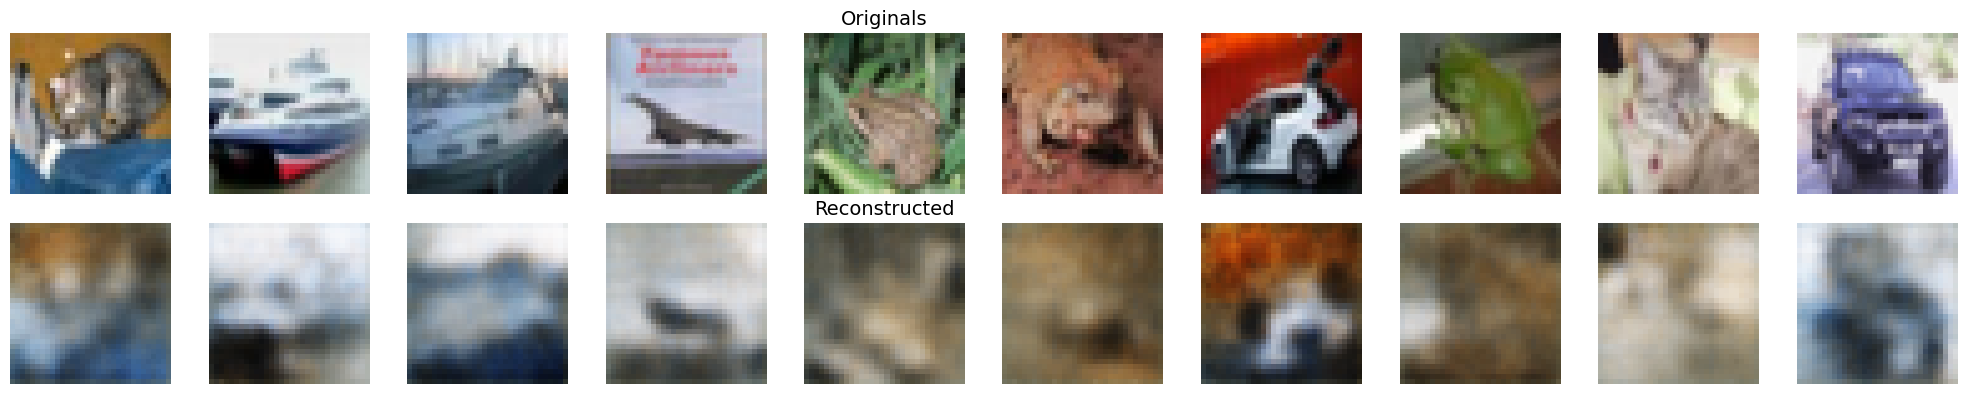

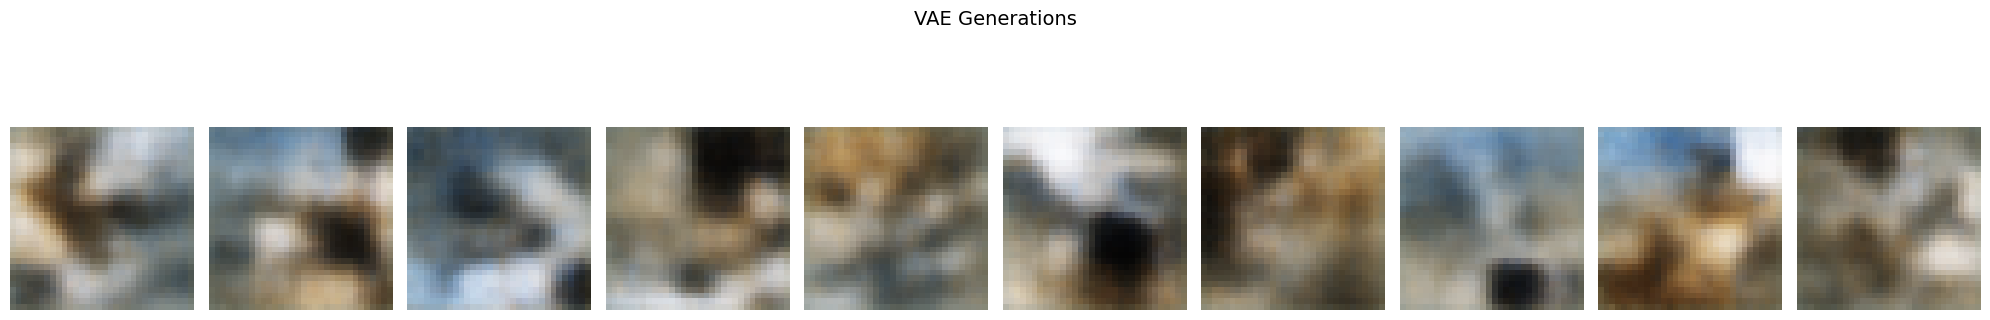

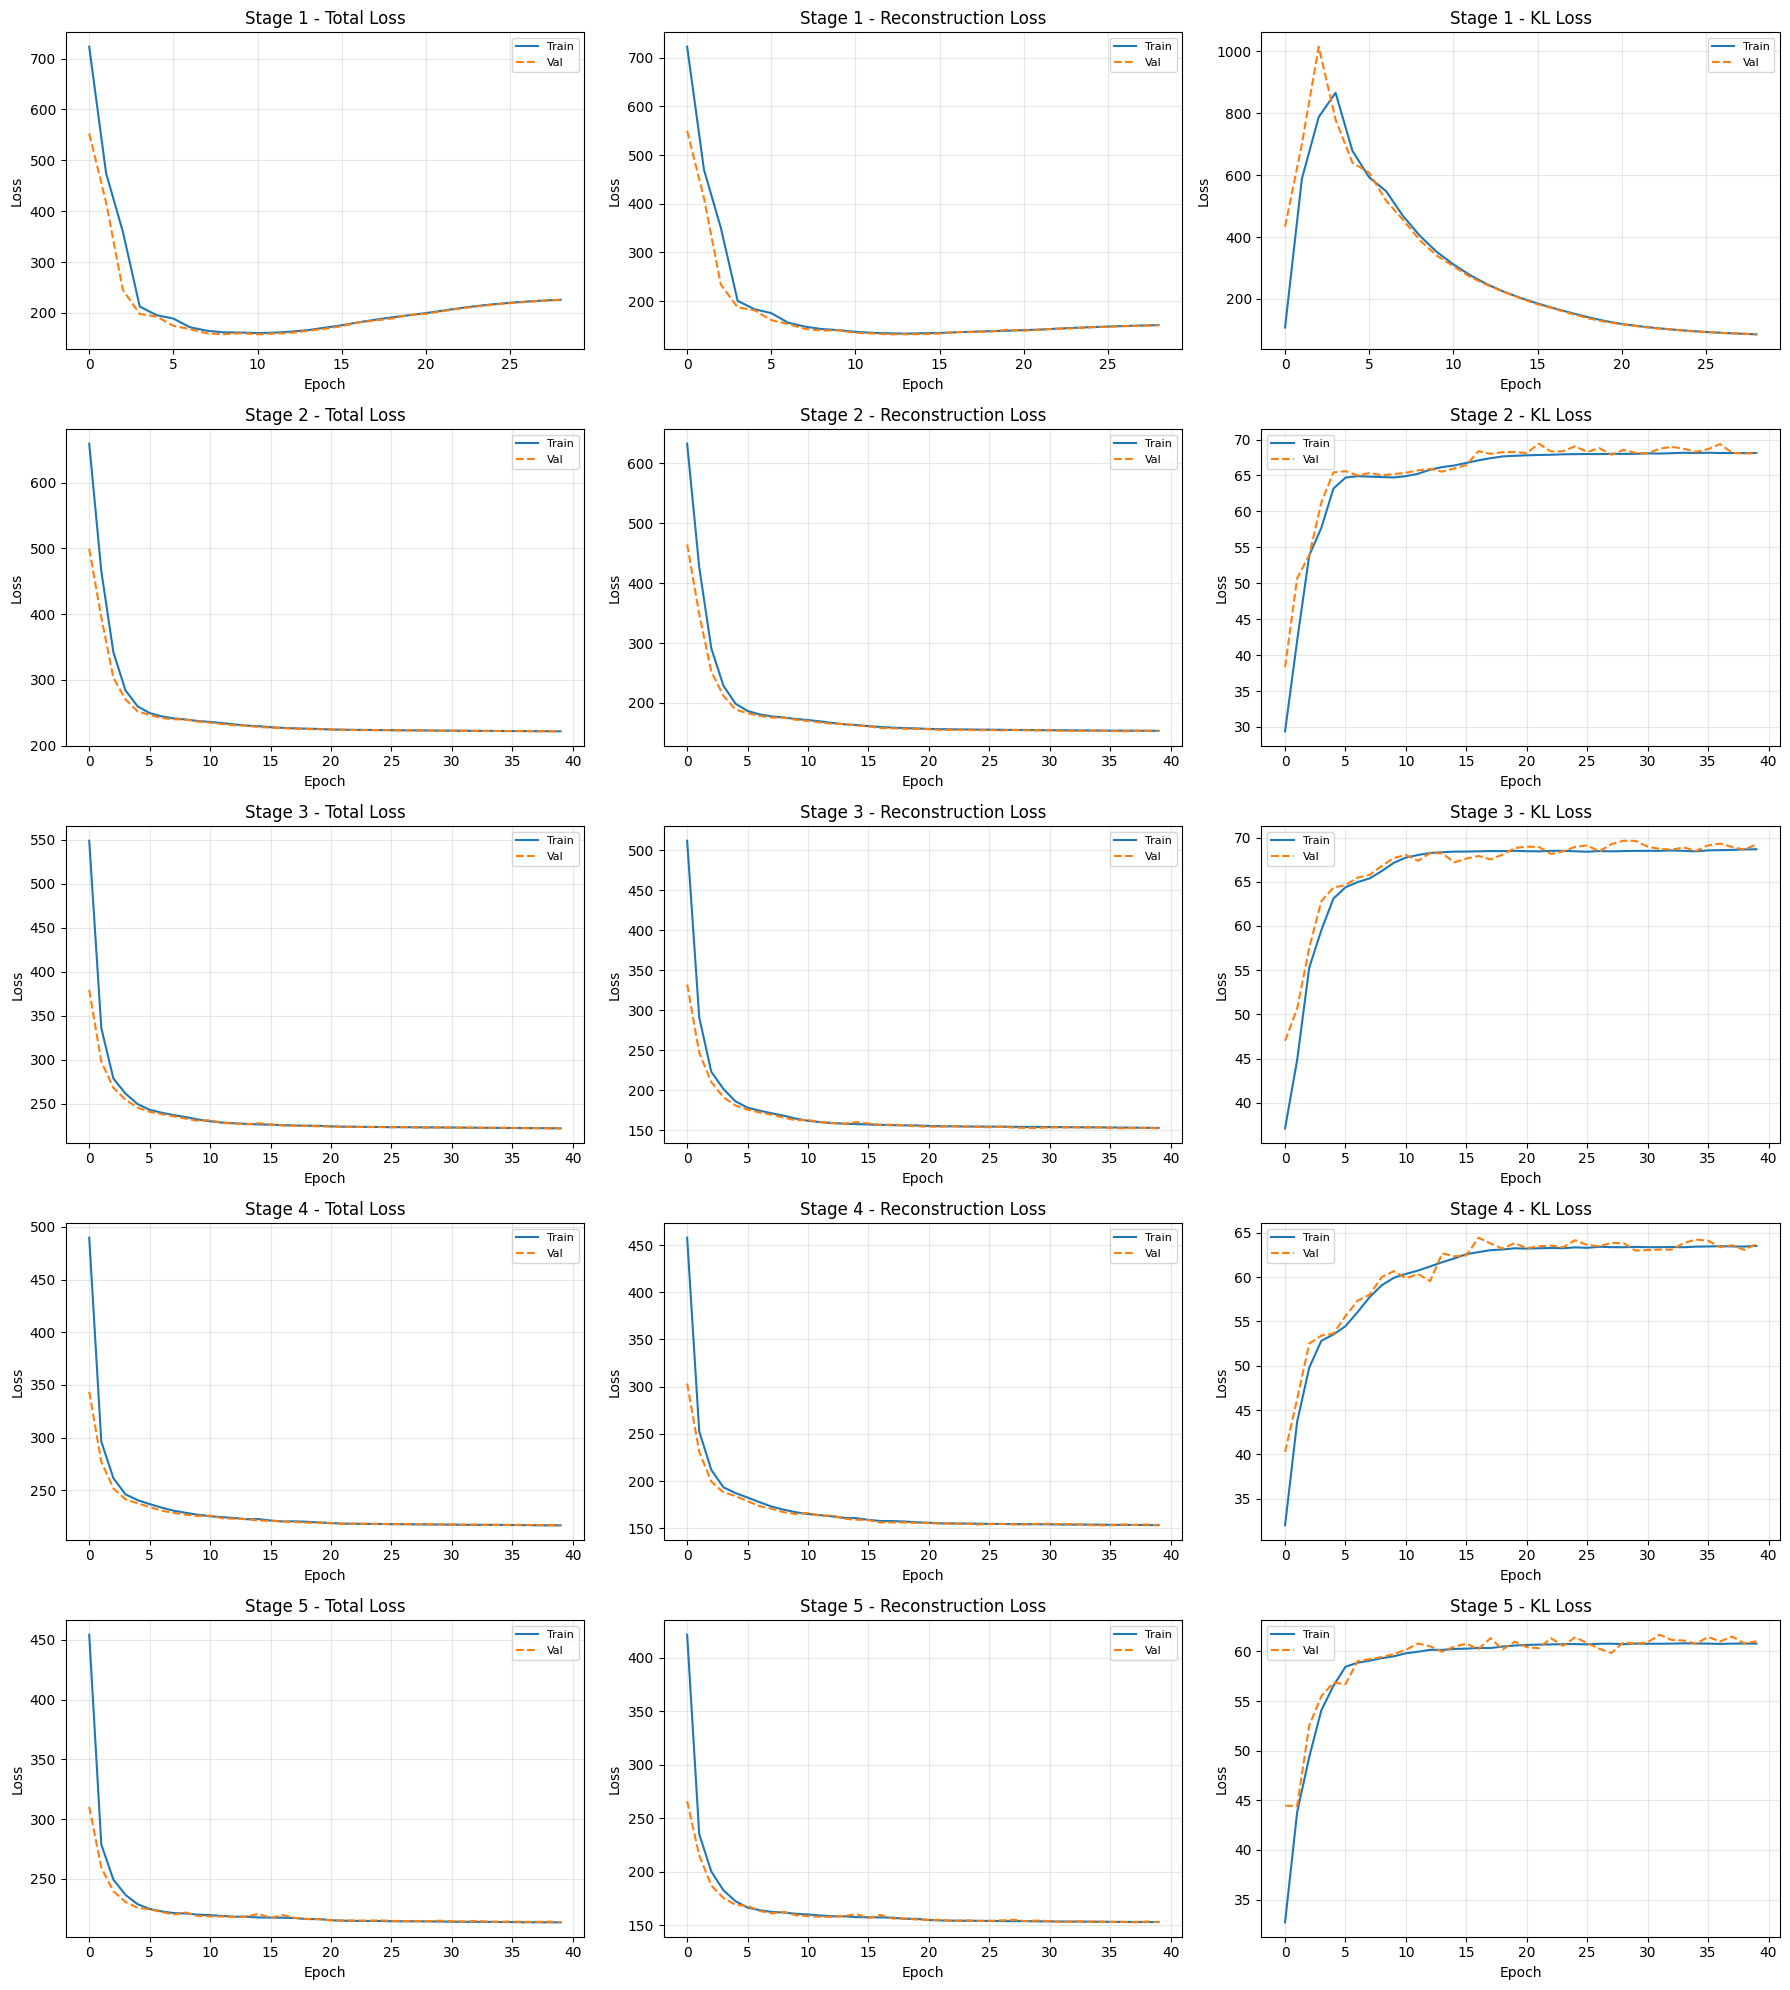

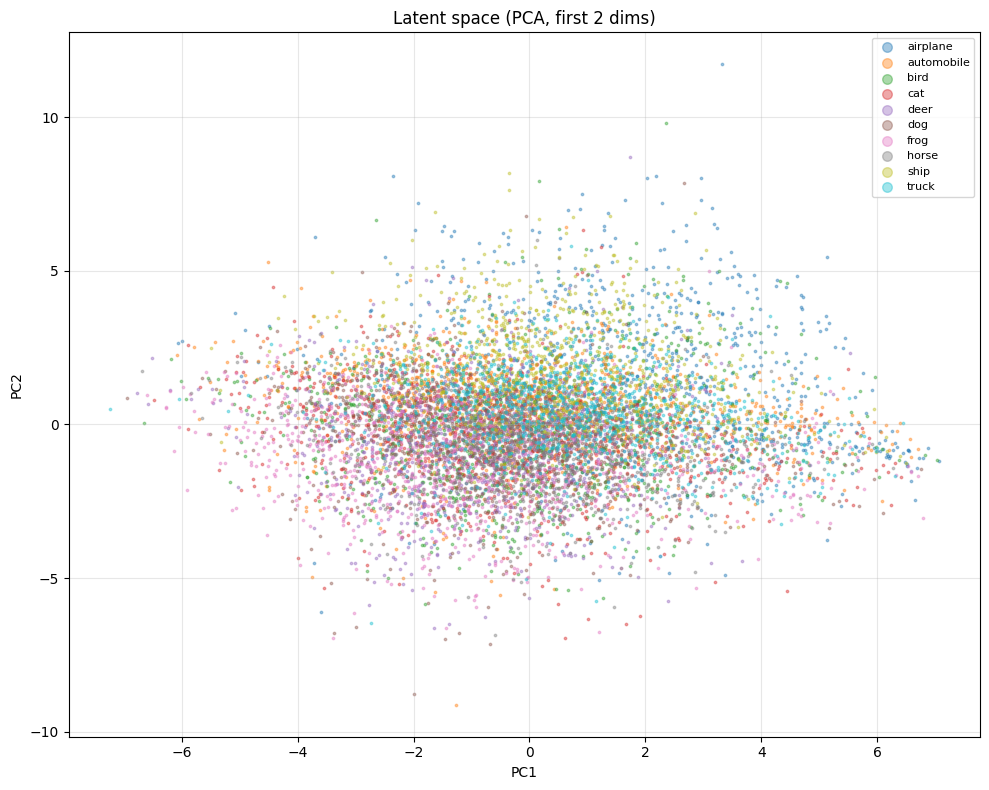

In [5]:
# Cell 5: Visualisations

def display(img):
    # Convert outputs to be displayable images in [0, 1], depending on output activation
    if ACTIVATION_OUT == 'tanh':
        return (np.clip(img, -1, 1) + 1) / 2
    elif ACTIVATION_OUT == 'sigmoid':
        return np.clip(img, 0, 1)

# Reconstructions
test_samples          = x_test[:10]
z_mean, z_log_var, z  = vae.encoder.predict(test_samples, verbose=0)
reconstructed         = vae.decoder.predict(z, verbose=0)
fig, axes             = plt.subplots(2, 10, figsize=(20, 4))
for i in range(10):
    axes[0, i].imshow(display(test_samples[i]))
    axes[0, i].axis('off')
    axes[1, i].imshow(display(reconstructed[i]))
    axes[1, i].axis('off')
axes[0, 4].set_title('Originals',     loc='center', fontsize=14)
axes[1, 4].set_title('Reconstructed', loc='center', fontsize=14)
plt.tight_layout()
plt.show()


# Generations from random latent samples
z_samples = np.random.normal(size=(10, BOTTLENECK_DIM, BOTTLENECK_DIM, LATENT_DIM))
generated = vae.decoder.predict(z_samples, verbose=0)
fig, axes = plt.subplots(1, 10, figsize=(20, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(display(generated[i]))
    ax.axis('off')
plt.suptitle('VAE Generations', fontsize=14)
plt.tight_layout()
plt.show()


# Loss curves per stage
n_stages  = len(histories)
fig, axes = plt.subplots(n_stages, 3, figsize=(18, 4 * n_stages))
panels    = [
    ('Total Loss',          'loss',       'val_loss'),
    ('Reconstruction Loss', 'recon_loss', 'val_recon_loss'),
    ('KL Loss',             'kl_loss',    'val_kl_loss'),
]
for stage_idx, hist in enumerate(histories):
    for col_idx, (title, train_key, val_key) in enumerate(panels):
        ax = axes[stage_idx, col_idx] if n_stages > 1 else axes[col_idx]
        ax.set_title(f'Stage {stage_idx + 1} - {title}')
        if train_key in hist: ax.plot(hist[train_key], label='Train')
        if val_key   in hist: ax.plot(hist[val_key],   linestyle='--', label='Val')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# Latent Space Visualisation
# PCA of the spatial latent space, coloured by class.
# A well-trained VAE should show smooth, overlapping blobs.

(_, y_test_labels) = keras.datasets.cifar10.load_data()[1]

z_means, _, _ = encoder.predict(x_test, verbose=0)

# Flatten spatial latent map to a vector per sample: (N, H, W, C) -> (N, H*W*C)
z_means_flat = z_means.reshape(z_means.shape[0], -1)

# Manual PCA using NumPy
z_centred            = z_means_flat - z_means_flat.mean(axis=0)
cov                  = np.cov(z_centred, rowvar=False)
eigenvals, eigenvecs = np.linalg.eigh(cov)
# eigh returns ascending order -- take the last 2 (largest variance)
top2 = eigenvecs[:, -2:][:, ::-1]
z_2d = z_centred @ top2

labels          = y_test_labels.flatten()
cifar10_classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

plt.figure(figsize=(10, 8))
for cls in range(10):
    mask = labels == cls
    plt.scatter(z_2d[mask, 0], z_2d[mask, 1], s=3, alpha=0.4, label=cifar10_classes[cls])
plt.title('Latent space (PCA, first 2 dims)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(markerscale=4, loc='best', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [6]:
# Cell 6: Metrics

# Final metrics summary
print('\nFinal stage metrics:')
for i, hist in enumerate(histories):
    print(f'  Stage {i+1}: total={hist["loss"][-1]:.5f}, recon={hist["recon_loss"][-1]:.5f}, kl={hist["kl_loss"][-1]:.5f}')

print('\nPer-epoch metrics:')

for i, hist in enumerate(histories):
    print(f'\nStage {i+1}')
    
    epochs = list(range(1, len(hist["loss"]) + 1))
    
    # Header row
    print('Epoch :', ' '.join(f'{e:5d}' for e in epochs))
    print('Total :', ' '.join(f'{v:5.4f}' for v in hist["loss"]))
    print('Recon :', ' '.join(f'{v:5.4f}' for v in hist["recon_loss"]))
    print('KL    :', ' '.join(f'{v:5.4f}' for v in hist["kl_loss"]))

# Display full model summary with all layers, including nested encoder and decoder, for final stage
vae.summary(expand_nested=True) 


Final stage metrics:
  Stage 1: total=225.83960, recon=150.61957, kl=85.39993
  Stage 2: total=221.56354, recon=153.43774, kl=68.12617
  Stage 3: total=221.83534, recon=153.15730, kl=68.67799
  Stage 4: total=216.78922, recon=153.27328, kl=63.51592
  Stage 5: total=213.78157, recon=152.98967, kl=60.79185

Per-epoch metrics:

Stage 1
Epoch :     1     2     3     4     5     6     7     8     9    10    11    12    13    14    15    16    17    18    19    20    21    22    23    24    25    26    27    28    29
Total : 723.3126 474.9533 359.3834 212.6350 195.5785 188.8370 171.6470 164.9724 161.7306 161.4325 160.4106 161.2198 163.2122 166.1937 170.9448 175.7352 181.4968 186.6933 191.3331 195.4091 199.6936 204.4634 209.2373 213.4686 217.0389 219.9942 222.3938 224.3121 225.8396
Recon : 722.5946 469.9068 350.7274 200.4489 183.3694 175.2201 155.5751 147.4835 142.5549 140.2609 136.7893 134.8646 133.7511 133.1617 133.9415 134.5076 135.9884 137.1028 138.1940 139.1392 140.3452 141.5605 143.332

Model: "vae_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_L5 (Functional)         │ ((None, 4, 4, 32),     │       626,928 │
│                                 │ (None, 4, 4, 32),      │               │
│                                 │ (None, 4, 4, 32))      │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_8 (InputLayer) │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_conv_0 (Conv2D)        │ (None, 16, 16, 16)     │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_1x1_0 (Conv2D)         │ (None, 16, 16, 16)     │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_conv_1 (Conv2D)        │ (None, 8, 8, 32)       │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_1x1_1 (Conv2D)         │ (None, 8, 8, 32)       │         1,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_conv_2 (Conv2D)        │ (None, 4, 4, 64)       │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_1x1_2 (Conv2D)         │ (None, 4, 4, 64)       │         4,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_conv_3 (Conv2D)        │ (None, 4, 4, 128)      │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_1x1_3 (Conv2D)         │ (None, 4, 4, 128)      │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_conv_4 (Conv2D)        │ (None, 4, 4, 256)      │       294,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ enc_1x1_4 (Conv2D)         │ (None, 4, 4, 256)      │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_mean (Conv2D)            │ (None, 4, 4, 32)       │        73,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ z_log_var (Conv2D)         │ (None, 4, 4, 32)       │        73,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ sampling_4 (Sampling)      │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_L5 (Functional)         │ (None, 32, 32, 3)      │       903,347 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ input_layer_9 (InputLayer) │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dec_input_proj (Conv2D)    │ (None, 4, 4, 256)      │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dec_1x1_4 (Conv2D)         │ (None, 4, 4, 256)      │        65,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dec_convT_4                │ (None, 4, 4, 256)      │       589,824 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dec_1x1_3 (Conv2D)         │ (None, 4, 4, 128)      │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dec_convT_3                │ (None, 4, 4, 128)      │       147,456 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│    └ dec_1x1_2 (Conv2D)         │ (None, 4, 4, 64)       │         8,19

 Total params: 3,874,190 (14.78 MB)

 Trainable params: 1,171,955 (4.47 MB)

 Non-trainable params: 358,320 (1.37 MB)

 Optimizer params: 2,343,915 (8.94 MB)

In [7]:
# Detailed epoch-by-epoch metrics summary
print('\nPer-epoch metrics:')
for i, hist in enumerate(histories):
    print(f'\nStage {i+1}')
    print('Epoch | Total | Recon | KL')
    print('----------------------------')
  
    for e, (t, r, k) in enumerate(zip(hist["loss"], hist["recon_loss"], hist["kl_loss"])):
        print(f'{e+1:5d} | {t:5.2f} | {r:5.2f} | {k:5.2f}')


Per-epoch metrics:

Stage 1
Epoch | Total | Recon | KL
----------------------------
    1 | 723.31 | 722.59 | 107.25
    2 | 474.95 | 469.91 | 588.34
    3 | 359.38 | 350.73 | 787.82
    4 | 212.64 | 200.45 | 866.50
    5 | 195.58 | 183.37 | 678.81
    6 | 188.84 | 175.22 | 592.62
    7 | 171.65 | 155.58 | 548.30
    8 | 164.97 | 147.48 | 468.53
    9 | 161.73 | 142.55 | 404.33
   10 | 161.43 | 140.26 | 352.35
   11 | 160.41 | 136.79 | 311.39
   12 | 161.22 | 134.86 | 276.41
   13 | 163.21 | 133.75 | 247.15
   14 | 166.19 | 133.16 | 223.12
   15 | 170.94 | 133.94 | 202.84
   16 | 175.74 | 134.51 | 185.13
   17 | 181.50 | 135.99 | 169.21
   18 | 186.69 | 137.10 | 154.57
   19 | 191.33 | 138.19 | 140.75
   20 | 195.41 | 139.14 | 128.52
   21 | 199.69 | 140.35 | 118.70
   22 | 204.46 | 141.56 | 111.89
   23 | 209.24 | 143.33 | 105.88
   24 | 213.47 | 145.00 | 100.81
   25 | 217.04 | 146.45 | 96.56
   26 | 219.99 | 147.73 | 92.97
   27 | 222.39 | 148.83 | 89.98
   28 | 224.31 | 149.76 | 8